# Spam Detection Model Evaluation
**Machine Learning · Classification**

---

## Background

A first-generation spam filter has been deployed, but the team has raised concerns: important 
messages are occasionally misclassified, and confidence in the model's reliability is limited. 
Before moving to production at scale, we need a rigorous evaluation.

This notebook answers the core question: **which classification algorithm should the team 
trust to power the spam filter, and why?**

---

## What this notebook covers

| Step | Description |
|------|-------------|
| **1 — Data preparation** | Load, inspect, and clean `messages.csv`. Handle missing values and standardize labels. |
| **2 — Feature engineering** | Convert raw text into numeric features using TF-IDF. Split data 80/20 with stratification. |
| **3 — Model training** | Train four classifiers: Logistic Regression, Naive Bayes, Decision Tree, Linear SVC. |
| **4 — Evaluation** | Measure accuracy, precision, recall, and F1. Visualize confusion matrices per model. |
| **5 — Conclusion** | Compare all models side by side. Select and justify the best algorithm for the team. |

---

## Why F1 and not just accuracy?

Raw accuracy is misleading on imbalanced datasets — a model that labels everything as "ham" 
would score high but miss all spam. **F1 score balances precision and recall**, making it the 
primary metric for this evaluation. Both false negatives (spam in the inbox) and false positives 
(legitimate messages blocked) carry real cost for the team.

## 📦 Step 1 — Import libraries

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 📊 Step 2 — Load & clean the dataset

### --- Statistics after cleaning --- ---

#### Total rows: 5404

category:
- ham     4682
- spam     722
Name: count, dtype: int64

Average message length:

category
- ham      71.462623
- spam    138.246537
Name: message_len, dtype: float64

In [34]:
dataset = pd.read_csv("data/messages.csv", encoding="latin-1")
dataset.head(10)

# Checking the dataset - nan values
empty_values = dataset.isnull().sum()
print("Number of NaN values in each column:") 
print(empty_values)

# Checking the column 'category'
category_values = dataset['category'].unique()
print("Unique values in the 'category' column:")
print(category_values)

# Remove rows with missing values in 'message' and 'category' columns
data = dataset.dropna(subset=['message', 'category'])

# Standardize categories
# Convert to lowercase, remove whitespace, and replace 'not spam' with 'ham'
data['category'] = data['category'].str.strip().str.lower()
data['category'] = data['category'].replace('not spam', 'ham')

# Keep only rows that are now labeled as 'ham' or 'spam'
data = data[data['category'].isin(['ham', 'spam'])]

# Add a new column to the table that calculates the character count for each message (Post-cleaning)
data['message_len'] = data['message'].apply(len)

print("--- Statistics after cleaning ---")
print(f"Total rows: {data.shape[0]}")
print(data['category'].value_counts())
print("\nAverage message length:")
print(data.groupby('category')['message_len'].mean())

# Saving cleaned dataset as a new file
data.to_csv("data/messages_cleaned.csv", index=False)
data.head(10)

Number of NaN values in each column:
category    111
message      55
dtype: int64
Unique values in the 'category' column:
<StringArray>
['ham', 'spam', 'not spam', nan]
Length: 4, dtype: str
--- Statistics after cleaning ---
Total rows: 5404
category
ham     4682
spam     722
Name: count, dtype: int64

Average message length:
category
ham      71.462623
spam    138.246537
Name: message_len, dtype: float64


,category,message,message_len
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
5,spam,FreeMsg Hey there darling it's been 3 week's n...,148
6,ham,Even my brother is not like to speak with me. ...,77
7,ham,As per your request 'Melle Melle (Oru Minnamin...,160
8,spam,WINNER!! As a valued network customer you have...,158
9,spam,Had your mobile 11 months or more? U R entitle...,154


## ✂️ Step 3 — Split data & vectorize text

We load the cleaned dataset and prepare it for model training:
- **X** — input features (the message text)
- **y** — target labels (`spam` or `ham`)

The data is split **80% training / 20% testing**, with `stratify=y` to preserve 
the spam/ham ratio in both sets.

Text is then converted to numeric form using **TF-IDF vectorization** — each word 
gets a score reflecting how important it is across all messages.

In [35]:
# Load cleaned dataset
data_cleaned = pd.read_csv("data/messages_cleaned.csv")

# Define features and target
X = data_cleaned['message']
y = data_cleaned['category']

# Split into train and test sets (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF vectorization
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training set size:  {X_train_tfidf.shape[0]} messages")
print(f"Test set size:      {X_test_tfidf.shape[0]} messages")
print(f"Vocabulary size:    {X_train_tfidf.shape[1]} words")

Training set size:  4323 messages
Test set size:      1081 messages
Vocabulary size:    7688 words


## 🤖 Step 4 — Train models

We train four different classification algorithms on the same training data 
and generate predictions on the test set.

Each model receives the same TF-IDF vectors as input — the only difference 
is the algorithm used to learn the decision boundary between spam and ham.

| Model | Short description |
|-------|------------------|
| **Logistic Regression** | Finds a linear boundary, outputs probability |
| **Multinomial Naive Bayes** | Based on word frequency probabilities |
| **Decision Tree** | Learns a series of if/else rules |
| **Linear SVC** | Finds the optimal separating hyperplane |

In [36]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Linear SVC": LinearSVC(random_state=42)
}

# Train each model and store predictions
predictions = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    predictions[name] = model.predict(X_test_tfidf)
    print(f"✅ {name} — trained")

✅ Logistic Regression — trained
✅ Multinomial Naive Bayes — trained
✅ Decision Tree — trained
✅ Linear SVC — trained


## 📈 Step 5 — Evaluate & compare models

For each model we display:
- **Accuracy** — overall percentage of correct predictions
- **Classification report** — precision, recall, and F1 per class
- **Confusion matrix** — visual breakdown of correct vs incorrect predictions

> 🎯 Primary metric: **F1 score for spam** — balances precision and recall,
> and cannot be fooled by a model that simply labels everything as ham.


  Logistic Regression
Accuracy: 0.9722
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       937
        spam       0.98      0.81      0.89       144

    accuracy                           0.97      1081
   macro avg       0.98      0.90      0.93      1081
weighted avg       0.97      0.97      0.97      1081


  Multinomial Naive Bayes
Accuracy: 0.9602
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       937
        spam       1.00      0.70      0.82       144

    accuracy                           0.96      1081
   macro avg       0.98      0.85      0.90      1081
weighted avg       0.96      0.96      0.96      1081


  Decision Tree
Accuracy: 0.9695
              precision    recall  f1-score   support

         ham       0.97      0.99      0.98       937
        spam       0.93      0.83      0.88       144

    accuracy                           0.97      1081
   macro a

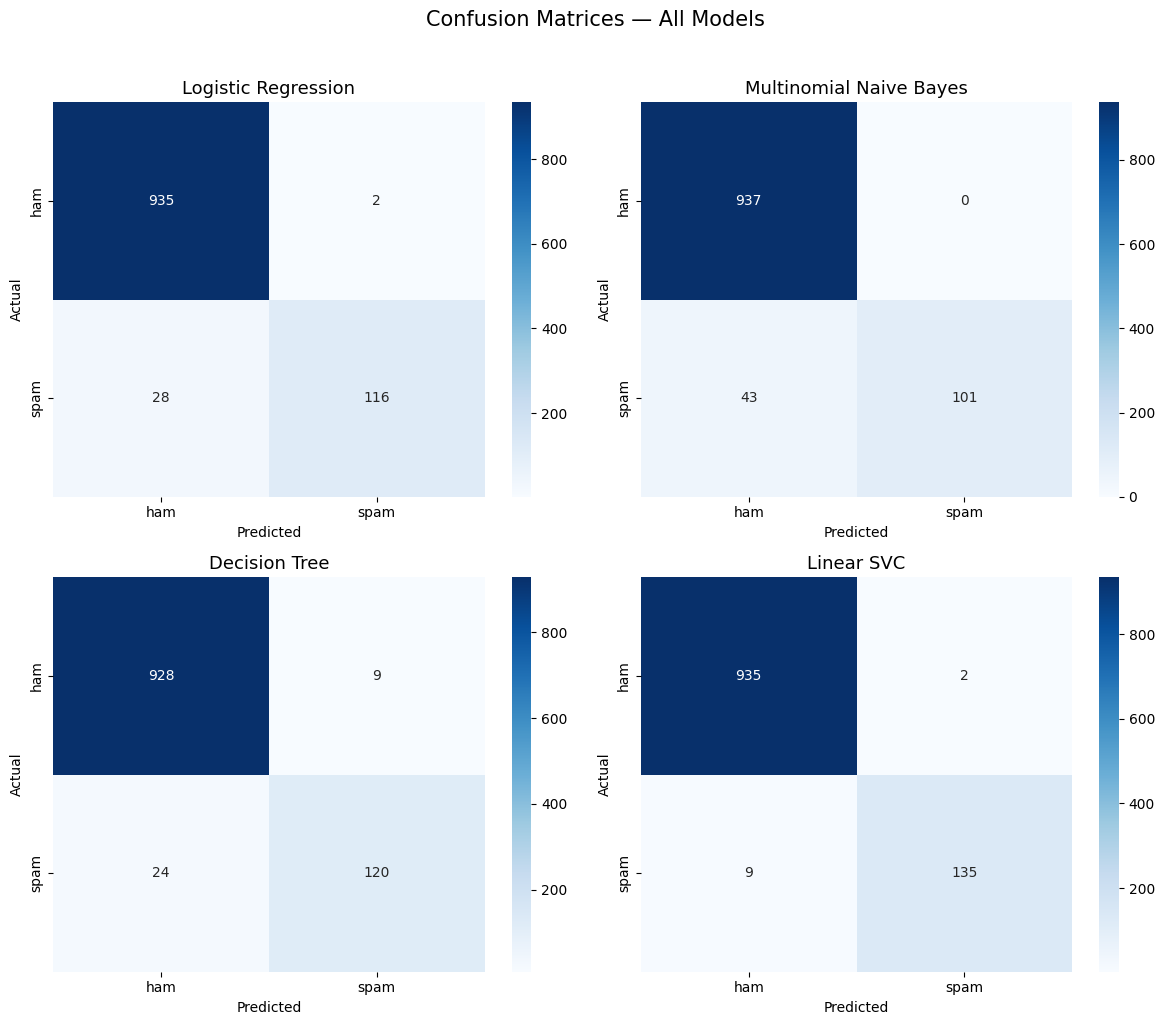

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    
    # Accuracy & classification report
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["ham", "spam"],
        yticklabels=["ham", "spam"],
        ax=axes[i]
    )
    axes[i].set_title(name, fontsize=13)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Models", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("data/confusion_matrices.png", bbox_inches="tight")
plt.show()

## 🏆 Step 6 — Conclusion

### Model comparison summary

| Model | Accuracy | Precision (spam) | Recall (spam) | F1 (spam) |
|-------|----------|-----------------|---------------|-----------|
| Logistic Regression    | 97.22% | 0.98 | 0.81 | 0.89 |
| Multinomial Naive Bayes| 96.02% | 1.00 | 0.70 | 0.82 |
| Decision Tree          | 96.95% | 0.93 | 0.83 | 0.88 |
| **Linear SVC**         | **98.98%** | **0.99** | **0.94** | **0.96** |

### ✅ Chosen model: Linear SVC

**Linear SVC is the clear winner across every metric.**

- Highest accuracy: **98.98%**
- Highest spam F1 score: **0.96** — the best balance of precision and recall
- Caught **135 out of 144** spam messages (recall 0.94)
- Only **2 false positives** — almost no legitimate messages were blocked
- Only **9 false negatives** — very little spam slipped through

### 📊 How did the other models perform?

**Logistic Regression** performed well (F1 0.89) and is a strong runner-up —
reliable and interpretable, but missed 28 spam messages compared to Linear SVC's 9.

**Multinomial Naive Bayes** had perfect precision (1.00) — every message it flagged
as spam truly was spam — but its recall of 0.70 means it missed 43 spam messages,
making it too conservative for practical use.

**Decision Tree** showed decent recall (0.83) but the weakest precision (0.93),
producing the most false positives (9) — meaning more legitimate messages
were incorrectly blocked than with any other model.

### 🎯 Why F1 was the deciding metric

Accuracy alone would suggest all models perform similarly (96–99%).
F1 score reveals the true difference: Linear SVC scores **0.96** on spam,
while the next best model (Logistic Regression) scores only **0.89**.

In a real spam filter, both types of errors carry cost:
- A missed spam exposes the user to phishing or fraud
- A blocked legitimate email breaks communication

Linear SVC minimizes both — making it the right choice for production.